# Challenge 3: Music Genre Classification

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
image = Image.open("Music.jpg")

## 1. Định nghĩa vấn đề (Define Problem)
+ **Mô tả**:
    + Bộ dữ liệu Music Genre Classification gồm thông tin về các bài hát kèm theo những đặc trưng âm thanh được trích xuất từ Spotify Audio Features. Mỗi bản ghi đại diện cho một bài nhạc với các thuộc tính như độ nhảy (danceability), năng lượng (energy), độ to (loudness), nhịp độ (tempo), thời lượng, độ “sáng” âm thanh (valence), mức độ lời thoại (speechiness)…
    + Mục tiêu: dự đoán thể loại nhạc (Class) của từng bài hát dựa trên các đặc trưng âm thanh.
    + Đây là bài toán phân loại đa lớp (multi-class classification).
+ **Dữ liệu vào (Features)**:
    1. Thông tin nhận dạng
    + Id: Mã định danh của bài hát
    + Artist Name: Tên nghệ sĩ
    + Track Name: Tên bài hát

    2. Đặc trưng âm thanh:
    + Popularity: Độ phổ biến của bài hát (0–100).
    + danceability: Mức độ phù hợp để nhảy (0–1).
    + energy: Mức năng lượng của bài hát (0–1).
    + key: Tông nhạc (0–11).
    + loudness: Độ lớn trung bình của âm thanh (đơn vị dB).
    + mode:
    1 = major
    0 = minor
    + speechiness: Mức độ chứa lời nói (rap có giá trị cao).
    + acousticness: Mức độ acoustic (0–1).
    + instrumentalness: Mức độ instrumental (không lời).
    + liveness: Khả năng được thu live.
    + valence: Mức độ “tươi vui” của âm thanh (0–1).
    + tempo: Nhịp độ (BPM).
    + duration_in min/ms: Thời lượng bài hát (ms).
    + time_signature: Chỉ số nhịp (3, 4,…).
+ **Kết quả**:
    + **Class**: Thể loại nhạc tương ứng của bài hát.
    + Đây là biến phân loại nhiều lớp.

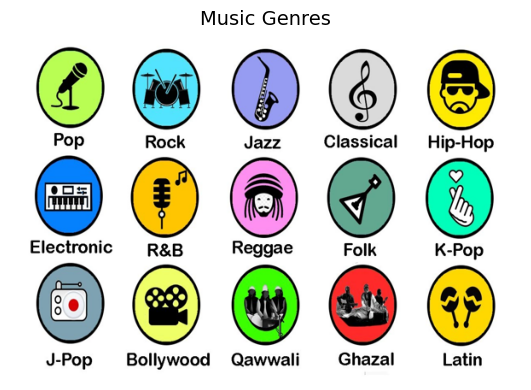

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(image.resize((600, 400)))
ax.axis("off")
ax.set_title("Music Genres", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

## 2. Chuẩn bị vấn đề (Prepare Problem)

### 2.1. Khai báo thư viện (Load Libraries)

In [3]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import warnings
%matplotlib inline
warnings.filterwarnings("ignore")

In [4]:
# params
seed = 42 

exps_dir = "../exps"
if os.path.exists(exps_dir) == False:
  os.makedirs(exps_dir, exist_ok=True)

save_dir = f"{exps_dir}/feature1"
os.makedirs(save_dir, exist_ok=True)

### 2.2. Nạp dữ liệu (Load Dataset)

In [5]:
# Load dataset
df_train = pd.read_csv("../../data03/train.csv")
df_test = pd.read_csv("../../data03/test.csv")

## 3. Loại bỏ các cột thực sự không mang thông tin

In [6]:
del_cols = ["Id", "Artist Name", "Track Name"]

def dropCol(df, cols):
    for name in cols:
        if name in df.columns:
            df.drop(name, axis=1, inplace=True)
    return df

In [7]:
dropCol(df_train,del_cols)
df_train.shape

(14396, 15)

In [8]:
dropCol(df_test,del_cols)
df_test.shape

(3600, 14)

## 4. Xử lý giá trị thiếu

### 4.1. Kiểm tra giá trị thiếu

In [9]:
def show_missing(df, title):
    print("="*10, title, "="*10)
    na = df.isna().sum()
    na = na[na > 0].sort_values(ascending=False)
    display(na)

show_missing(df_train, "Missing Values - Train")
show_missing(df_test, "Missing Values - Test")

========== Missing Values - Train ==========


instrumentalness    3541
key                 1609
Popularity           333
dtype: int64

========== Missing Values - Test ==========


instrumentalness    836
key                 405
Popularity           95
dtype: int64

In [10]:
missing_percent = (df_train.isna().sum() / len(df_train) * 100).sort_values(ascending=False)
missing_percent

instrumentalness      24.597110
key                   11.176716
Popularity             2.313143
energy                 0.000000
loudness               0.000000
mode                   0.000000
danceability           0.000000
speechiness            0.000000
acousticness           0.000000
liveness               0.000000
valence                0.000000
tempo                  0.000000
duration_in min/ms     0.000000
time_signature         0.000000
Class                  0.000000
dtype: float64

In [11]:
df_train.head()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9
1,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6
2,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10
3,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2
4,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5


In [12]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Popularity          14063 non-null  float64
 1   danceability        14396 non-null  float64
 2   energy              14396 non-null  float64
 3   key                 12787 non-null  float64
 4   loudness            14396 non-null  float64
 5   mode                14396 non-null  int64  
 6   speechiness         14396 non-null  float64
 7   acousticness        14396 non-null  float64
 8   instrumentalness    10855 non-null  float64
 9   liveness            14396 non-null  float64
 10  valence             14396 non-null  float64
 11  tempo               14396 non-null  float64
 12  duration_in min/ms  14396 non-null  float64
 13  time_signature      14396 non-null  int64  
 14  Class               14396 non-null  int64  
dtypes: float64(12), int64(3)
memory usage: 1.6 MB


In [13]:
def report_missing(df, name="df"):
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f"\nMissing in {name}: {miss.shape[0]} columns")
    if miss.shape[0] > 0:
        print(miss)
    else:
        print("No missing values")

report_missing(df_train, "df_train (before)")
report_missing(df_test, "df_test (before)")


Missing in df_train (before): 3 columns
instrumentalness    3541
key                 1609
Popularity           333
dtype: int64

Missing in df_test (before): 3 columns
instrumentalness    836
key                 405
Popularity           95
dtype: int64


### 4.2. Điền giá trị thiếu

In [14]:
# Sao chép
df_train = df_train.copy()
df_test  = df_test.copy()

# 1. Điền missing cho Popularity (median)
df_train['Popularity'].fillna(df_train['Popularity'].median(), inplace=True)
df_test['Popularity'].fillna(df_train['Popularity'].median(), inplace=True)

# 2. Điền missing cho key (mode)
df_train['key'].fillna(df_train['key'].mode()[0], inplace=True)
df_test['key'].fillna(df_train['key'].mode()[0], inplace=True)

# 3. Điền missing cho instrumentalness (median)
df_train['instrumentalness'].fillna(df_train['instrumentalness'].median(), inplace=True)
df_test['instrumentalness'].fillna(df_train['instrumentalness'].median(), inplace=True)

In [15]:
report_missing(df_train, "df_train (after)")
report_missing(df_test,  "df_test (after)")


Missing in df_train (after): 0 columns
No missing values

Missing in df_test (after): 0 columns
No missing values


**Nhận xét**:
- Tập dữ liệu có 3 cột chứa giá trị thiếu: instrumentalness, key và Popularity.

- Các giá trị thiếu được xử lý bằng cách:

    + điền median cho Popularity và instrumentalness để tránh ảnh hưởng của ngoại lai,

    + điền mode cho key do đây là biến rời rạc (0–11).

- Sau khi thay thế, toàn bộ tập dữ liệu không còn missing values và sẵn sàng cho bước tiền xử lý tiếp theo.

## 5. Chuẩn hóa dữ liệu (Scaling)

In [16]:
from sklearn.preprocessing import StandardScaler

# ---- Tách target ----
y = df_train["Class"].copy()

X_train = df_train.drop(columns=["Class"])
X_test  = df_test.copy()

# ---- Scale tất cả cột số ----
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print("Các cột được scale:", num_cols)

scaler = StandardScaler()
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Scaling finished.")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

# ---- Gắn lại target để train ----
df_train_scaled = X_train.copy()
df_train_scaled["Class"] = y.values

df_test_scaled = X_test.copy()

Các cột được scale: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature']
Scaling finished.
X_train shape: (14396, 14)
X_test shape : (3600, 14)


In [17]:
df_train_scaled.to_excel(f'{exps_dir}/data/train.xlsx', index=None)
df_test_scaled.to_excel(f'{exps_dir}/data/test.xlsx', index=None)

OSError: Cannot save file into a non-existent directory: '..\exps\data'